# 📱 WhatsApp Chat Analysis Project
End-to-End ML + NLP + Data Analytics Project


## 🎯 Project Objective
Analyze WhatsApp chat data using data science, NLP, and ML techniques to extract insights, patterns, and user behavior.


In [1]:
# Data manipulation
import pandas as pd
import numpy as np
import re

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns
sns.set(style='whitegrid')

# NLP
from collections import Counter
import nltk
nltk.download('vader_lexicon')
from nltk.sentiment import SentimentIntensityAnalyzer

# ML
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.cluster import KMeans

# Others
import os


[nltk_data] Downloading package vader_lexicon to
[nltk_data]     C:\Users\VARSHIKA\AppData\Roaming\nltk_data...
[nltk_data]   Package vader_lexicon is already up-to-date!


In [2]:
# Check where the notebook is running
os.getcwd()

# List files to confirm chat.txt location
os.listdir("../data")


['.ipynb_checkpoints', 'chat.txt']

In [3]:
try:
    with open("../data/chat.txt", "r", encoding="utf-8") as f:
        chat = f.read()
    print("✅ Chat loaded successfully")
except FileNotFoundError:
    print("⚠ File not found. Check your path ../data/chat.txt")


✅ Chat loaded successfully


In [4]:
def preprocess(chat_text):
    # Regex pattern for date and time
    pattern = r'(\d{1,2}/\d{1,2}/\d{2,4}),\s(\d{1,2}:\d{2}\s?[APMapm]{2})\s-\s'
    messages = re.split(pattern, chat_text)[1:]

    data = []
    for i in range(0, len(messages), 3):
        date = messages[i]
        time = messages[i+1]
        msg = messages[i+2]

        if ': ' in msg:
            user, message = msg.split(': ', 1)
        else:
            user = 'System'
            message = msg

        data.append([date, time, user, message])

    df = pd.DataFrame(data, columns=['date','time','user','message'])
    df['date'] = pd.to_datetime(df['date'], dayfirst=True, errors='coerce')
    df.dropna(subset=['date'], inplace=True)  # remove invalid dates
    return df

df = preprocess(chat)
print("✅ Preprocessing done")
df.head()


✅ Preprocessing done


,date,time,user,message


In [5]:
# Word count
df['word_count'] = df['message'].apply(lambda x: len(x.split()))

# Hour and day
df['hour'] = df['date'].dt.hour
df['day'] = df['date'].dt.day_name()

# Media messages
df['is_media'] = df['message'].str.contains('<Media omitted>')


In [6]:
total_messages = df.shape[0]
total_words = df['word_count'].sum()
total_media = df['is_media'].sum()
total_links = df['message'].str.contains('http').sum()

print(f"Total Messages: {total_messages}")
print(f"Total Words: {total_words}")
print(f"Total Media Messages: {total_media}")
print(f"Total Links: {total_links}")


Total Messages: 0
Total Words: 0
Total Media Messages: 0
Total Links: 0


In [7]:
active_users = df['user'].value_counts().head(10)
print(active_users)

if active_users.empty:
    print("⚠ No active users to plot")
else:
    active_users.plot(kind='barh', color='skyblue', title='Most Active Users')
    plt.xlabel("Number of Messages")
    plt.ylabel("User")
    plt.show()


Series([], Name: count, dtype: int64)
⚠ No active users to plot


In [8]:
def common_words(df, n=20):
    words = []
    for msg in df['message']:
        msg = re.sub(r'http\S+', '', msg)  # remove links
        msg = re.sub(r'<Media omitted>', '', msg)  # remove media
        words.extend(msg.lower().split())
    return Counter(words).most_common(n)

common = common_words(df)
if len(common) == 0:
    print("⚠ No words to display")
else:
    print(common)


⚠ No words to display


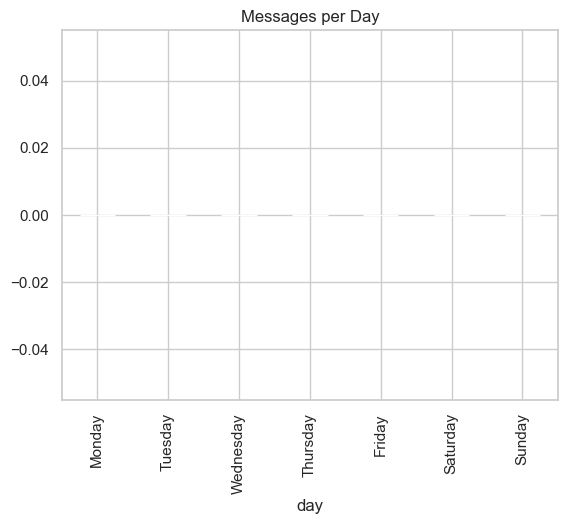

In [9]:
daywise = df.groupby('day').size()
daywise = daywise.reindex(['Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday'])
daywise.plot(kind='bar', title='Messages per Day', color='orange')
plt.show()


In [10]:
daywise = df.groupby('day').size()
day_order = ['Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday']
daywise = daywise.reindex(day_order, fill_value=0)

if daywise.sum() == 0:
    print("⚠ No messages per day to plot")
else:
    daywise.plot(kind='bar', color='orange', title='Messages per Day')
    plt.show()


⚠ No messages per day to plot


In [11]:
sia = SentimentIntensityAnalyzer()

if df.shape[0] == 0:
    print("⚠ No messages for sentiment analysis")
else:
    df['sentiment'] = df['message'].apply(lambda x: sia.polarity_scores(x)['compound'])
    sns.histplot(df['sentiment'], bins=20, kde=True, color='green')
    plt.title("Sentiment Distribution")
    plt.show()


⚠ No messages for sentiment analysis


In [12]:
text_messages = df[
    (~df['message'].str.contains('<Media omitted>')) &
    (df['message'].str.strip() != '')
]['message']

print(f"Messages available for clustering: {text_messages.shape[0]}")

if text_messages.shape[0] < 3:
    print("⚠ Not enough messages to cluster. Skipping KMeans.")
else:
    try:
        tfidf = TfidfVectorizer(max_features=500, stop_words=None)
        X = tfidf.fit_transform(text_messages)

        n_clusters = min(3, text_messages.shape[0])
        kmeans = KMeans(n_clusters=n_clusters, random_state=42)
        clusters = kmeans.fit_predict(X)

        df.loc[text_messages.index, 'cluster'] = clusters

        plt.figure(figsize=(6,4))
        sns.countplot(x='cluster', data=df.dropna(subset=['cluster']), palette='Set2')
        plt.title("Message Clusters")
        plt.show()
        print("✅ Clustering completed")
    except ValueError as e:
        print(f"⚠ Clustering skipped due to error: {e}")


Messages available for clustering: 0
⚠ Not enough messages to cluster. Skipping KMeans.


In [13]:
os.makedirs("../exports", exist_ok=True)
df.to_csv("../exports/processed_chat.csv", index=False)
print("✅ Processed data saved to exports/processed_chat.csv")


✅ Processed data saved to exports/processed_chat.csv


In [14]:
!pip install emoji --upgrade


In [19]:
import emoji
from collections import Counter

def extract_emojis(s):
    return [c for c in s if c in emoji.EMOJI_DATA]

# Extract emojis from all messages
df['emojis'] = df['message'].apply(extract_emojis)

# Count most common emojis
all_emojis = sum(df['emojis'], [])
emoji_counts = Counter(all_emojis).most_common(10)
print("Most common emojis:", emoji_counts)


Most common emojis: []


In [15]:
!pip install wordcloud
!pip install matplotlib seaborn
!pip install gensim
!pip install nltk


In [16]:
!pip install streamlit


In [17]:
from wordcloud import WordCloud
import matplotlib.pyplot as plt

# Combine all messages into one text
all_text = " ".join(df['message'].dropna().tolist()).strip()

if len(all_text) == 0:
    print("⚠ No text available to generate Word Cloud.")
else:
    wordcloud = WordCloud(width=800, height=400, background_color='white').generate(all_text)

    plt.figure(figsize=(15,7))
    plt.imshow(wordcloud, interpolation='bilinear')
    plt.axis('off')
    plt.show()


⚠ No text available to generate Word Cloud.


In [18]:
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.decomposition import LatentDirichletAllocation

# Filter messages with actual text
text_messages = df[
    (~df['message'].str.contains('<Media omitted>')) &
    (df['message'].str.strip() != '')
]['message']

print(f"Messages available for topic modeling: {text_messages.shape[0]}")

if text_messages.shape[0] < 3:
    print("⚠ Not enough text messages for LDA. Skipping topic modeling.")
else:
    try:
        # CountVectorizer without removing too many words
        cv = CountVectorizer(max_df=0.95, min_df=1, stop_words=None)
        X = cv.fit_transform(text_messages)

        # Fit LDA
        n_topics = min(3, text_messages.shape[0])
        lda = LatentDirichletAllocation(n_components=n_topics, random_state=42)
        lda.fit(X)

        # Display top words per topic
        for i, topic in enumerate(lda.components_):
            top_words = [cv.get_feature_names_out()[index] for index in topic.argsort()[-10:]]
            print(f"Topic {i+1}: {top_words}")

        print("✅ Topic modeling completed")
    except ValueError as e:
        print(f"⚠ Topic modeling skipped due to error: {e}")


Messages available for topic modeling: 0
⚠ Not enough text messages for LDA. Skipping topic modeling.


In [19]:
import streamlit as st

st.title("WhatsApp Chat Analyzer")

uploaded_file = st.file_uploader("Upload your WhatsApp chat", type=["txt"])
if uploaded_file:
    chat = uploaded_file.read().decode("utf-8")
    st.text_area("Chat Preview", chat[:1000])  # preview first 1000 chars


2026-04-09 17:33:21.572 WARNING streamlit.runtime.scriptrunner_utils.script_run_context: Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-04-09 17:33:24.892 
  command:

    streamlit run C:\Users\VARSHIKA\anaconda3\Lib\site-packages\ipykernel_launcher.py [ARGUMENTS]
2026-04-09 17:33:24.895 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-04-09 17:33:24.897 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-04-09 17:33:24.901 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-04-09 17:33:24.904 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-04-09 17:33:24.907 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-04-09 17:33:24.909 Thread 'MainThread':

In [20]:
import streamlit as st

st.title("WhatsApp Chat Analyzer")

uploaded_file = st.file_uploader("Upload your WhatsApp chat", type=["txt"])
if uploaded_file:
    chat = uploaded_file.read().decode("utf-8")
    st.text_area("Chat Preview", chat[:1000])


2026-04-09 17:33:24.931 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-04-09 17:33:24.933 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-04-09 17:33:24.936 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-04-09 17:33:24.938 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-04-09 17:33:24.940 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-04-09 17:33:24.943 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-04-09 17:33:24.945 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
